# Starter Notebook: Qwen 2B LoRA for Text-to-SVG (Kaggle)

This starter is built from the resources in `contest_docs`:
- Data resources: `contest_docs/03_Data_Design.md`
- Baseline and starter guidance: `contest_docs/05_Baselines_and_Starter_Notebooks.md`
- Kaggle implementation notes: `contest_docs/06_Kaggle_Implementation_Guide.md`

Goal: provide a practical scaffold for Qwen-2B-class fine-tuning + submission generation.

## Referenced Data and Docs

### Dataset resources from `contest_docs/03_Data_Design.md`
- `OmniSVG/MMSVG-Icon`
- `xingxm/SVGX-Core-250k`
- `xingxm/SVGX-SFT-1M` (recommended subset: `SVGX_SFT_GEN_51k.json`)
- `nyuuzyou/svgfind`
- `starvector/svg-icons`
- `thesantatitan/deepseek-svg-dataset`
- `InternSVG/SArena` (evaluation benchmark)

### Qwen 2B fine-tuning references from `contest_docs/05` and `contest_docs/06`
- Unsloth Qwen fine-tune docs: https://unsloth.ai/docs/models/qwen3.5/fine-tune
- Qwen3.5-2B Vision notebook: https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Qwen3_5_(2B)_Vision.ipynb

Note: this notebook is written as a reusable starter. You may need to adjust exact model IDs and column names to match the latest upstream datasets.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
shutil.copytree(
    "/content/qwen25_15b_base",
    "/content/drive/MyDrive/qwen25_15b_base",
    dirs_exist_ok=True
)
print("copied")

copied


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
from pathlib import Path

BASE_LOCAL = Path("/content/drive/MyDrive/qwen25_15b_base")

print("exists:", BASE_LOCAL.exists())
print("files:", [p.name for p in BASE_LOCAL.iterdir()])

tok = AutoTokenizer.from_pretrained(BASE_LOCAL, trust_remote_code=True)
print("tokenizer ok")

model = AutoModelForCausalLM.from_pretrained(
    BASE_LOCAL,
    torch_dtype=torch.float16,
    trust_remote_code=True,
)
print("model ok")

exists: True
files: ['tokenizer_config.json', 'config.json', 'model-00001-of-00002.safetensors', 'chat_template.jinja', 'model-00002-of-00002.safetensors', 'tokenizer.json', 'generation_config.json', 'model.safetensors.index.json']
tokenizer ok


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

model ok


In [ ]:
import shutil

archive = shutil.make_archive(
    "/content/drive/MyDrive/qwen25_15b_base",
    "zip",
    "/content/drive/MyDrive/qwen25_15b_base"
)
print(archive)

/content/drive/MyDrive/qwen25_15b_base.zip


In [ ]:
# ===== INSTALL BLOCK =====
%%capture
%pip install -U pip setuptools wheel
%pip install -U transformers datasets accelerate peft bitsandbytes sentencepiece scikit-learn cairosvg scikit-image pillow

print("Install finished. Restart runtime, then continue.")

In [11]:
%pip install -U cairosvg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 5.8 MB/s eta 0:00:00


In [2]:
# ===== MOUNT + CONFIG BLOCK =====
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import os, re, gc, json, math, time, random, warnings
from io import BytesIO
from pathlib import Path
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 3407
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("GPU is required.")

gpu_name = torch.cuda.get_device_name(0)
print("GPU:", gpu_name)

DATA_DIR = Path("/content/drive/MyDrive/DL_midterm")
RUN_NAME = "svg_a100_stable_assistant_only_v1"

CONFIG = {
    "base_model": "Qwen/Qwen2.5-1.5B-Instruct",

    "train_path": str(DATA_DIR / "train.csv"),
    "test_path": str(DATA_DIR / "test.csv"),
    "sample_submission_path": str(DATA_DIR / "sample_submission.csv"),

    "work_dir": str(DATA_DIR / RUN_NAME),
    "adapter_dir": str(DATA_DIR / RUN_NAME / "adapter"),

    "max_seq_length": 2048,
    "max_svg_chars_hard": 16000,
    "svg_round_decimals": 2,

    "val_frac": 0.025,
    "min_prompt_chars": 3,
    "min_svg_chars": 40,

    "char_outlier_q": 0.995,
    "token_outlier_q": 0.995,

    "lora_r": 32,
    "lora_alpha": 64,
    "lora_dropout": 0.05,

    # A100 配置
    "per_device_train_batch_size": 8,
    "per_device_eval_batch_size": 8,
    "gradient_accumulation_steps": 2,

    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.03,
    "num_train_epochs": 2.0,

    "logging_steps": 10,
    "eval_steps": 100,
    "save_steps": 100,
    "save_total_limit": 2,

    "early_stopping_patience": 3,

    "gen_max_new_tokens": 384,
    "infer_batch_size": 12,
    "repetition_penalty": 1.02,
}

Path(CONFIG["work_dir"]).mkdir(parents=True, exist_ok=True)
Path(CONFIG["adapter_dir"]).mkdir(parents=True, exist_ok=True)

SYSTEM_PROMPT = (
    "Generate only valid SVG markup for a simple icon or symbol that matches the user's request. "
    "Use exactly one root <svg xmlns='http://www.w3.org/2000/svg'> element. "
    "Return SVG only. No markdown. No explanation. No comments. No chat tags. "
    "Keep the SVG compact, semantically faithful, and visually centered."
)

print(json.dumps(CONFIG, indent=2))

Mounted at /content/drive
GPU: Tesla T4
{
  "base_model": "Qwen/Qwen2.5-1.5B-Instruct",
  "train_path": "/content/drive/MyDrive/DL_midterm/train.csv",
  "test_path": "/content/drive/MyDrive/DL_midterm/test.csv",
  "sample_submission_path": "/content/drive/MyDrive/DL_midterm/sample_submission.csv",
  "work_dir": "/content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1",
  "adapter_dir": "/content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1/adapter",
  "max_seq_length": 2048,
  "max_svg_chars_hard": 16000,
  "svg_round_decimals": 2,
  "val_frac": 0.025,
  "min_prompt_chars": 3,
  "min_svg_chars": 40,
  "char_outlier_q": 0.995,
  "token_outlier_q": 0.995,
  "lora_r": 32,
  "lora_alpha": 64,
  "lora_dropout": 0.05,
  "per_device_train_batch_size": 8,
  "per_device_eval_batch_size": 8,
  "gradient_accumulation_steps": 2,
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.03,
  "num_train_epochs": 2.0,
  "logging_steps": 10,
  "eval_steps": 100,


In [3]:
# ===== SVG CLEANING UTILS BLOCK =====
SVG_START_RE = re.compile(r"<svg\b", flags=re.IGNORECASE)
SVG_END_RE = re.compile(r"</svg\s*>", flags=re.IGNORECASE)
XML_DECL_RE = re.compile(r"<\?xml[\s\S]*?\?>", flags=re.IGNORECASE)
DOCTYPE_RE = re.compile(r"<!DOCTYPE[\s\S]*?>", flags=re.IGNORECASE)
COMMENT_RE = re.compile(r"<!--[\s\S]*?-->", flags=re.IGNORECASE)
CODE_FENCE_RE = re.compile(r"```(?:svg)?|```", flags=re.IGNORECASE)
MULTISPACE_RE = re.compile(r"\s+")
NUMBER_RE = re.compile(r"(?<![A-Za-z])[-+]?(?:\d+\.\d+|\d+|\.\d+)(?:[eE][-+]?\d+)?")

ALLOWED_TAGS = {
    "svg", "g", "path", "rect", "circle", "ellipse", "line", "polyline", "polygon",
    "defs", "use", "symbol", "clipPath", "mask", "linearGradient", "radialGradient",
    "stop", "text", "tspan", "title", "desc", "style", "pattern", "marker", "filter"
}
VISIBLE_SHAPE_TAGS = {"path", "rect", "circle", "ellipse", "line", "polyline", "polygon", "text", "use"}

def pick_col(df, candidates, name):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    raise ValueError(f"Cannot find {name} column. Available columns: {list(df.columns)}")

def normalize_prompt_text(x):
    return " ".join(str(x).strip().split())

def local_name(tag_or_attr):
    s = str(tag_or_attr)
    if "}" in s:
        s = s.split("}", 1)[1]
    if ":" in s:
        s = s.split(":", 1)[1]
    return s

def extract_svg(text):
    if not isinstance(text, str):
        return ""
    text = CODE_FENCE_RE.sub("", text)
    text = XML_DECL_RE.sub("", text)
    text = DOCTYPE_RE.sub("", text)
    text = COMMENT_RE.sub("", text)
    text = text.strip()
    m = SVG_START_RE.search(text)
    if not m:
        return ""
    text = text[m.start():]
    end_matches = list(SVG_END_RE.finditer(text))
    if end_matches:
        text = text[:end_matches[-1].end()]
    return text.strip()

def strip_namespace_inplace(elem):
    elem.tag = local_name(elem.tag)
    new_attrib = {}
    for k, v in elem.attrib.items():
        new_attrib[local_name(k)] = v
    elem.attrib.clear()
    elem.attrib.update(new_attrib)
    for child in list(elem):
        strip_namespace_inplace(child)

def prune_disallowed_children(elem):
    for child in list(elem):
        if local_name(child.tag) not in ALLOWED_TAGS:
            elem.remove(child)
        else:
            prune_disallowed_children(child)

def strip_unsafe_attrs_inplace(elem):
    for attr in list(elem.attrib.keys()):
        name = local_name(attr).lower()
        val = str(elem.attrib[attr]).strip()

        if name.startswith("on"):
            del elem.attrib[attr]
            continue
        if name in {"href", "xlink:href"} and re.match(r"^(https?:)?//", val, flags=re.IGNORECASE):
            del elem.attrib[attr]
            continue
        if name in {"class", "data-name", "aria-label", "aria-hidden"}:
            del elem.attrib[attr]
            continue
    for child in list(elem):
        strip_unsafe_attrs_inplace(child)

def normalize_numeric_string(x, decimals=2):
    try:
        v = float(x)
    except Exception:
        return x
    if abs(v) < 1e-12:
        v = 0.0
    s = f"{v:.{decimals}f}".rstrip("0").rstrip(".")
    if s == "-0":
        s = "0"
    return s

def compact_path_d(d, decimals=2):
    def repl(m):
        return normalize_numeric_string(m.group(0), decimals=decimals)
    d = NUMBER_RE.sub(repl, str(d))
    d = re.sub(r"\s*,\s*", ",", d)
    d = re.sub(r"\s+", " ", d).strip()
    d = re.sub(r"([A-Za-z])\s+", r"\1", d)
    d = re.sub(r"\s+([A-Za-z])", r"\1", d)
    d = re.sub(r"(\d)-", r"\1 -", d)
    return d

def compact_attribs_inplace(elem, decimals=2):
    numeric_like = {
        "x", "y", "x1", "y1", "x2", "y2", "cx", "cy", "r", "rx", "ry",
        "width", "height", "stroke-width", "stroke-miterlimit", "opacity",
        "fill-opacity", "stroke-opacity", "offset", "font-size"
    }
    for k in list(elem.attrib.keys()):
        v = str(elem.attrib[k]).strip()
        if k == "d":
            elem.attrib[k] = compact_path_d(v, decimals=decimals)
        elif k in numeric_like:
            elem.attrib[k] = normalize_numeric_string(v, decimals=decimals)
        else:
            elem.attrib[k] = MULTISPACE_RE.sub(" ", v).strip()
    for child in list(elem):
        compact_attribs_inplace(child, decimals=decimals)

def strip_empty_text_inplace(elem):
    if elem.text is not None:
        elem.text = elem.text.strip()
        if elem.text == "":
            elem.text = None
    if elem.tail is not None:
        elem.tail = elem.tail.strip()
        if elem.tail == "":
            elem.tail = None
    for child in list(elem):
        strip_empty_text_inplace(child)

def count_visible_shapes(root):
    return sum(1 for e in root.iter() if local_name(e.tag) in VISIBLE_SHAPE_TAGS)

def minify_svg(svg_text, decimals=2, max_chars=16000):
    svg_text = extract_svg(svg_text)
    if not svg_text or len(svg_text) > max_chars * 4:
        return ""

    try:
        root = ET.fromstring(svg_text)
    except Exception:
        return ""

    strip_namespace_inplace(root)
    if local_name(root.tag) != "svg":
        return ""

    prune_disallowed_children(root)
    strip_unsafe_attrs_inplace(root)
    compact_attribs_inplace(root, decimals=decimals)
    strip_empty_text_inplace(root)

    if count_visible_shapes(root) == 0:
        return ""

    root.attrib["xmlns"] = "http://www.w3.org/2000/svg"
    root.attrib["width"] = root.attrib.get("width", "256")
    root.attrib["height"] = root.attrib.get("height", "256")
    root.attrib["viewBox"] = root.attrib.get("viewBox", "0 0 256 256")

    out = ET.tostring(root, encoding="unicode", short_empty_elements=True)
    out = MULTISPACE_RE.sub(" ", out).replace("> <", "><").strip()

    if len(out) > max_chars:
        return ""
    return out

In [4]:
# ===== LOAD + CLEAN TRAIN BLOCK =====
raw_train_df = pd.read_csv(CONFIG["train_path"])

PROMPT_COL = pick_col(raw_train_df, ["prompt", "description", "text", "instruction"], "prompt")
SVG_COL    = pick_col(raw_train_df, ["svg", "output", "target", "label"], "svg")

train_df = raw_train_df[[PROMPT_COL, SVG_COL]].rename(columns={PROMPT_COL: "prompt", SVG_COL: "svg"}).copy()
train_df["prompt"] = train_df["prompt"].astype(str).map(normalize_prompt_text)
train_df["svg"] = train_df["svg"].astype(str)

before = len(train_df)
train_df = train_df[train_df["prompt"].str.len() >= CONFIG["min_prompt_chars"]].copy()

train_df["raw_chars"] = train_df["svg"].str.len()
train_df["svg_min"] = train_df["svg"].map(
    lambda x: minify_svg(
        x,
        decimals=CONFIG["svg_round_decimals"],
        max_chars=CONFIG["max_svg_chars_hard"],
    )
)
train_df["min_chars"] = train_df["svg_min"].str.len()

train_df = train_df[train_df["svg_min"].str.len() >= CONFIG["min_svg_chars"]].copy()
train_df["prompt_norm"] = train_df["prompt"].str.lower()
train_df = train_df.drop_duplicates(subset=["prompt_norm", "svg_min"]).copy()

char_cut = int(train_df["min_chars"].quantile(CONFIG["char_outlier_q"]))
train_df = train_df[train_df["min_chars"] <= char_cut].copy()
train_df = train_df.reset_index(drop=True)

print(f"Rows before cleaning: {before}")
print(f"Rows after cleaning:  {len(train_df)}")
print(f"Char cutoff: {char_cut}")

print("\nmin_chars stats:")
print(train_df["min_chars"].describe([0.5, 0.9, 0.95, 0.99]))

preview_df = train_df.assign(
    saved_chars=train_df["raw_chars"] - train_df["min_chars"],
    compress_ratio=(train_df["min_chars"] / train_df["raw_chars"]).round(3)
).sort_values("saved_chars", ascending=False).head(10)

preview_df[["prompt", "raw_chars", "min_chars", "saved_chars", "compress_ratio"]]

Rows before cleaning: 50000
Rows after cleaning:  49736
Char cutoff: 5799

min_chars stats:
count    49736.000000
mean      1199.007761
std        706.427548
min        118.000000
50%       1034.000000
90%       2191.000000
95%       2563.000000
99%       3188.000000
max       5799.000000
Name: min_chars, dtype: float64


,prompt,raw_chars,min_chars,saved_chars,compress_ratio
48243,A black cross symbol is located next to an emp...,9041,3628,5413,0.401
31113,不允许吃东西或不允许饮料图标。,9406,3994,5412,0.425
37251,A ticket icon with an X mark above it.,9180,3780,5400,0.412
25114,A black silhouette of an object resembling a f...,7986,2746,5240,0.344
24951,The image shows a black gear-like icon on a wh...,7807,2629,5178,0.337
12520,"A white line graph icon on a black background,...",7802,2624,5178,0.336
19281,A simple blue outline resembling a swimsuit or...,7990,2818,5172,0.353
47318,The image contains three black rectangular sha...,7584,2428,5156,0.320
28686,The image features two black cylindrical objec...,7948,2793,5155,0.351
22190,A blue calendar icon with white lines and tabs...,7814,2665,5149,0.341


In [5]:
# ===== LOAD TOKENIZER + SPLIT BLOCK =====
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(CONFIG["base_model"], trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

def render_prompt_only(prompt):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt},
    ]
    try:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    except TypeError:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

def count_svg_tokens(svg):
    return len(tokenizer(svg, add_special_tokens=False)["input_ids"])

def count_total_tokens(prompt, svg):
    prompt_text = render_prompt_only(prompt)
    full_text = prompt_text + svg + (tokenizer.eos_token or "")
    return len(tokenizer(full_text, add_special_tokens=False)["input_ids"])

train_df["svg_tokens"] = train_df["svg_min"].map(count_svg_tokens)
train_df["total_tokens"] = [
    count_total_tokens(p, s)
    for p, s in zip(train_df["prompt"].tolist(), train_df["svg_min"].tolist())
]

hard_max = CONFIG["max_seq_length"] - 8
token_cut = min(hard_max, int(train_df["total_tokens"].quantile(CONFIG["token_outlier_q"])))

before_tok = len(train_df)
train_df = train_df[
    (train_df["svg_tokens"] >= 8) &
    (train_df["total_tokens"] <= hard_max) &
    (train_df["total_tokens"] <= token_cut)
].copy().reset_index(drop=True)

print(f"Rows before token filtering: {before_tok}")
print(f"Rows after token filtering:  {len(train_df)}")
print(f"Token cutoff: {token_cut}")

try:
    n_bins = min(10, train_df["total_tokens"].nunique())
    bins = pd.qcut(train_df["total_tokens"], q=n_bins, duplicates="drop").astype(str)
    train_part, val_part = train_test_split(
        train_df,
        test_size=CONFIG["val_frac"],
        random_state=SEED,
        stratify=bins,
    )
except Exception:
    train_part, val_part = train_test_split(
        train_df,
        test_size=CONFIG["val_frac"],
        random_state=SEED,
        shuffle=True,
    )

train_part = train_part.reset_index(drop=True)
val_part = val_part.reset_index(drop=True)

print("Train rows:", len(train_part))
print("Val rows:", len(val_part))

train_part.to_csv(Path(CONFIG["work_dir"]) / "train_clean_split.csv", index=False)
val_part.to_csv(Path(CONFIG["work_dir"]) / "val_clean_split.csv", index=False)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Rows before token filtering: 49736
Rows after token filtering:  44169
Token cutoff: 2040
Train rows: 43064
Val rows: 1105


In [6]:
# ===== BUILD TOKENIZED DATASET BLOCK =====
from datasets import Dataset

def build_example(prompt, svg):
    prompt_text = render_prompt_only(prompt)
    full_text = prompt_text + svg + (tokenizer.eos_token or "")

    prompt_ids = tokenizer(prompt_text, add_special_tokens=False)["input_ids"]
    full_ids = tokenizer(full_text, add_special_tokens=False)["input_ids"]

    if len(full_ids) > CONFIG["max_seq_length"]:
        full_ids = full_ids[:CONFIG["max_seq_length"]]

    prompt_len = min(len(prompt_ids), len(full_ids))
    labels = [-100] * prompt_len + full_ids[prompt_len:]

    attention_mask = [1] * len(full_ids)

    return {
        "input_ids": full_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }

def df_to_dataset(df):
    rows = []
    for p, s in zip(df["prompt"].tolist(), df["svg_min"].tolist()):
        rows.append(build_example(p, s))
    return Dataset.from_list(rows)

train_dataset = df_to_dataset(train_part)
val_dataset = df_to_dataset(val_part)

print(train_dataset[0].keys())
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Example input length:", len(train_dataset[0]["input_ids"]))
print("Supervised label tokens:", sum(int(x != -100) for x in train_dataset[0]["labels"]))

dict_keys(['input_ids', 'attention_mask', 'labels'])
Train size: 43064
Val size: 1105
Example input length: 967
Supervised label tokens: 868


In [7]:
# ===== LOAD BASE MODEL + LORA BLOCK =====
from transformers import AutoModelForCausalLM, DataCollatorForSeq2Seq
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print("Using dtype:", DTYPE)

model = AutoModelForCausalLM.from_pretrained(
    CONFIG["base_model"],
    torch_dtype=DTYPE,
    device_map="auto",
    trust_remote_code=True,
)

model.config.use_cache = False
if hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable()

peft_config = LoraConfig(
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    lora_dropout=CONFIG["lora_dropout"],
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"],
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt",
)

`torch_dtype` is deprecated! Use `dtype` instead!


Using dtype: torch.bfloat16


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 36,929,536 || all params: 1,580,643,840 || trainable%: 2.3364


In [6]:
# ===== TRAINING BLOCK =====
import inspect
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback

candidate_args = dict(
    output_dir=CONFIG["work_dir"],

    per_device_train_batch_size=CONFIG["per_device_train_batch_size"],
    per_device_eval_batch_size=CONFIG["per_device_eval_batch_size"],
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],

    learning_rate=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
    warmup_ratio=CONFIG["warmup_ratio"],
    num_train_epochs=CONFIG["num_train_epochs"],
    lr_scheduler_type="cosine",

    logging_steps=CONFIG["logging_steps"],
    eval_steps=CONFIG["eval_steps"],
    save_steps=CONFIG["save_steps"],

    evaluation_strategy="steps",
    eval_strategy="steps",
    save_strategy="steps",

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=CONFIG["save_total_limit"],

    report_to="none",
    seed=SEED,

    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),

    optim="adamw_torch",
    max_grad_norm=0.3,
    remove_unused_columns=False,
)

supported_keys = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
filtered_args = {k: v for k, v in candidate_args.items() if k in supported_keys}

if "evaluation_strategy" in filtered_args and "eval_strategy" in filtered_args:
    filtered_args.pop("eval_strategy", None)

training_args = TrainingArguments(**filtered_args)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=CONFIG["early_stopping_patience"])],
)

print("base_model =", CONFIG["base_model"])
print("max_seq_length =", CONFIG["max_seq_length"])
print("per_device_train_batch_size =", CONFIG["per_device_train_batch_size"])
print("gradient_accumulation_steps =", CONFIG["gradient_accumulation_steps"])
print("bf16 =", torch.cuda.is_bf16_supported())
print("fp16 =", not torch.cuda.is_bf16_supported())

train_result = trainer.train()
print(train_result)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


NameError: name 'model' is not defined

In [ ]:
# ===== SAVE ADAPTER BLOCK =====
model.config.use_cache = True

model.save_pretrained(CONFIG["adapter_dir"])
tokenizer.save_pretrained(CONFIG["adapter_dir"])

print("Saved adapter to:", CONFIG["adapter_dir"])
print("Saved train split to:", Path(CONFIG["work_dir"]) / "train_clean_split.csv")
print("Saved val split to:", Path(CONFIG["work_dir"]) / "val_clean_split.csv")

experimental results

In [8]:
# ===== REPORT HELPER BLOCK =====
import os, math, json, random, textwrap
from pathlib import Path
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

import cairosvg

try:
    from skimage.metrics import structural_similarity as ssim_metric
except Exception:
    ssim_metric = None

REPORT_DIR = Path(CONFIG["work_dir"]) / "report_assets"
FIG_DIR = REPORT_DIR / "figures"
TABLE_DIR = REPORT_DIR / "tables"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("REPORT_DIR =", REPORT_DIR)

def save_table(df, name):
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"Saved table -> {path}")
    return path

def save_plot(fig, name, dpi=180):
    path = FIG_DIR / f"{name}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure -> {path}")
    return path

def render_svg_white(svg_text, size=256):
    try:
        png_bytes = cairosvg.svg2png(
            bytestring=str(svg_text).encode("utf-8"),
            output_width=size,
            output_height=size,
        )
        img = Image.open(BytesIO(png_bytes)).convert("RGBA")
        white = Image.new("RGBA", img.size, (255, 255, 255, 255))
        white.alpha_composite(img)
        return white.convert("RGB")
    except Exception:
        return Image.new("RGB", (size, size), (255, 255, 255))

def pil_to_gray_np(img):
    return np.asarray(img.convert("L"), dtype=np.float32) / 255.0

def compute_ssim_proxy(pred_svg, gt_svg, size=256):
    pred = render_svg_white(pred_svg, size=size)
    gt = render_svg_white(gt_svg, size=size)
    pred_g = pil_to_gray_np(pred)
    gt_g = pil_to_gray_np(gt)
    if ssim_metric is None:
        mse = np.mean((pred_g - gt_g) ** 2)
        return float(max(0.0, 1.0 - mse))
    return float(ssim_metric(pred_g, gt_g, data_range=1.0))

def edge_map_from_svg(svg_text, size=256, thresh_q=0.90):
    arr = pil_to_gray_np(render_svg_white(svg_text, size=size))
    gx = np.abs(np.diff(arr, axis=1, prepend=arr[:, :1]))
    gy = np.abs(np.diff(arr, axis=0, prepend=arr[:1, :]))
    mag = np.sqrt(gx * gx + gy * gy)
    thresh = float(np.quantile(mag, thresh_q))
    return mag >= thresh

def compute_edge_f1_proxy(pred_svg, gt_svg, size=256):
    ep = edge_map_from_svg(pred_svg, size=size)
    eg = edge_map_from_svg(gt_svg, size=size)
    tp = np.logical_and(ep, eg).sum()
    fp = np.logical_and(ep, np.logical_not(eg)).sum()
    fn = np.logical_and(np.logical_not(ep), eg).sum()
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    return float(2 * precision * recall / (precision + recall + 1e-9))

def count_paths(svg_text):
    try:
        root = ET.fromstring(str(svg_text))
        return sum(1 for e in root.iter() if local_name(e.tag) == "path")
    except Exception:
        return np.nan

def infer_mode_name():
    if "generate_best_svg_batch" in globals():
        return "two_candidate_rerank"
    elif "generate_svg_batch" in globals():
        return "single_candidate"
    return "unknown"

def batch_generate_for_report(prompts, max_new_tokens=None):
    if "generate_best_svg_batch" in globals():
        return generate_best_svg_batch(prompts)
    elif "generate_svg_batch" in globals():
        return generate_svg_batch(prompts, max_new_tokens=max_new_tokens)
    else:
        raise RuntimeError("No generation function found. Run your generation block first.")

print("Generation mode detected:", infer_mode_name())

ModuleNotFoundError: No module named 'cairosvg'

,statistic,value
0,raw_training_rows,50000.00
1,rows_after_cleaning,44169.00
2,train_split_rows,43064.00
3,val_split_rows,1105.00
4,mean_prompt_chars,116.80
5,mean_svg_chars,1018.49
6,p90_svg_chars,1733.00
7,mean_svg_tokens,877.48
8,mean_total_tokens,985.14
9,p90_total_tokens,1681.00


Saved table -> /content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1/report_assets/tables/dataset_summary.csv
Saved figure -> /content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1/report_assets/figures/dataset_histograms.png


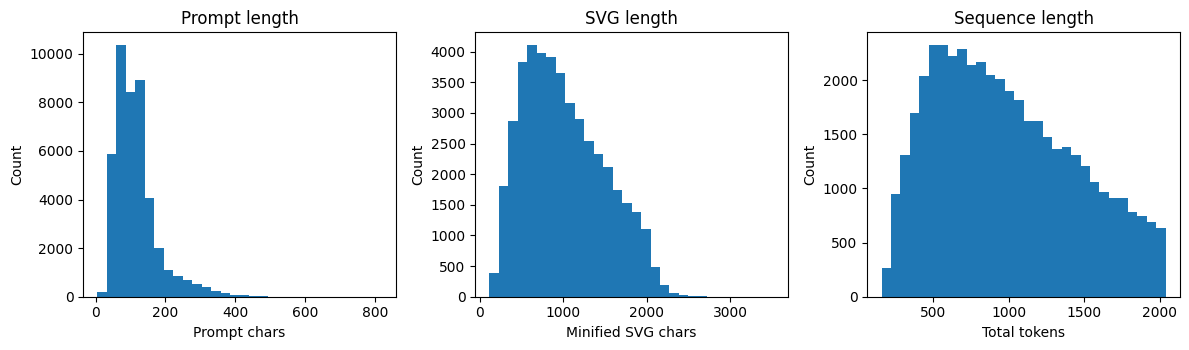

In [10]:
# ===== REPORT CELL A: DATASET SUMMARY + HISTOGRAMS =====
dataset_summary_df = pd.DataFrame([
    {"statistic": "raw_training_rows", "value": len(raw_train_df)},
    {"statistic": "rows_after_cleaning", "value": len(train_df)},
    {"statistic": "train_split_rows", "value": len(train_part)},
    {"statistic": "val_split_rows", "value": len(val_part)},
    {"statistic": "mean_prompt_chars", "value": round(float(train_df["prompt"].str.len().mean()), 2)},
    {"statistic": "mean_svg_chars", "value": round(float(train_df["min_chars"].mean()), 2)},
    {"statistic": "p90_svg_chars", "value": round(float(train_df["min_chars"].quantile(0.90)), 2)},
    {"statistic": "mean_svg_tokens", "value": round(float(train_df["svg_tokens"].mean()), 2)},
    {"statistic": "mean_total_tokens", "value": round(float(train_df["total_tokens"].mean()), 2)},
    {"statistic": "p90_total_tokens", "value": round(float(train_df["total_tokens"].quantile(0.90)), 2)},
])

display(dataset_summary_df)
save_table(dataset_summary_df, "dataset_summary")

fig = plt.figure(figsize=(12, 3.6))

plt.subplot(1, 3, 1)
plt.hist(train_df["prompt"].str.len(), bins=30)
plt.xlabel("Prompt chars")
plt.ylabel("Count")
plt.title("Prompt length")

plt.subplot(1, 3, 2)
plt.hist(train_df["min_chars"], bins=30)
plt.xlabel("Minified SVG chars")
plt.ylabel("Count")
plt.title("SVG length")

plt.subplot(1, 3, 3)
plt.hist(train_df["total_tokens"], bins=30)
plt.xlabel("Total tokens")
plt.ylabel("Count")
plt.title("Sequence length")

save_plot(fig, "dataset_histograms")
plt.show()

In [11]:
# ===== REPORT CELL B: MODEL/TRAIN CONFIG + TRAINING CURVES =====
model_train_cfg = pd.DataFrame([
    {"item": "base_model", "value": CONFIG["base_model"]},
    {"item": "max_seq_length", "value": CONFIG["max_seq_length"]},
    {"item": "lora_r", "value": CONFIG["lora_r"]},
    {"item": "lora_alpha", "value": CONFIG["lora_alpha"]},
    {"item": "lora_dropout", "value": CONFIG["lora_dropout"]},
    {"item": "per_device_train_batch_size", "value": CONFIG["per_device_train_batch_size"]},
    {"item": "per_device_eval_batch_size", "value": CONFIG["per_device_eval_batch_size"]},
    {"item": "gradient_accumulation_steps", "value": CONFIG["gradient_accumulation_steps"]},
    {"item": "learning_rate", "value": CONFIG["learning_rate"]},
    {"item": "weight_decay", "value": CONFIG["weight_decay"]},
    {"item": "warmup_ratio", "value": CONFIG["warmup_ratio"]},
    {"item": "num_train_epochs", "value": CONFIG["num_train_epochs"]},
    {"item": "early_stopping_patience", "value": CONFIG["early_stopping_patience"]},
    {"item": "gen_max_new_tokens", "value": CONFIG["gen_max_new_tokens"]},
    {"item": "infer_batch_size", "value": CONFIG["infer_batch_size"]},
    {"item": "repetition_penalty", "value": CONFIG["repetition_penalty"]},
    {"item": "generation_mode_detected", "value": infer_mode_name()},
    {"item": "seed", "value": SEED},
    {"item": "gpu_name", "value": gpu_name},
])

display(model_train_cfg)
save_table(model_train_cfg, "model_and_train_config")

log_history = []
if "trainer" in globals() and hasattr(trainer, "state") and hasattr(trainer.state, "log_history"):
    log_history = trainer.state.log_history

if len(log_history) == 0:
    print("No trainer.state.log_history found.")
else:
    log_df = pd.DataFrame(log_history)
    display(log_df.tail(10))

    fig = plt.figure(figsize=(6.5, 4.0))
    if "loss" in log_df.columns:
        tmp = log_df[["step", "loss"]].dropna()
        if len(tmp) > 0:
            plt.plot(tmp["step"], tmp["loss"], label="train_loss")
    if "eval_loss" in log_df.columns:
        tmp = log_df[["step", "eval_loss"]].dropna()
        if len(tmp) > 0:
            plt.plot(tmp["step"], tmp["eval_loss"], label="eval_loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Training / validation loss")
    plt.legend()
    save_plot(fig, "training_curves")
    plt.show()

,item,value
0,base_model,Qwen/Qwen2.5-1.5B-Instruct
1,max_seq_length,2048
2,lora_r,32
3,lora_alpha,64
4,lora_dropout,0.05
5,per_device_train_batch_size,8
6,per_device_eval_batch_size,8
7,gradient_accumulation_steps,2
8,learning_rate,0.00002
9,weight_decay,0.01


Saved table -> /content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1/report_assets/tables/model_and_train_config.csv
No trainer.state.log_history found.


In [12]:
# ===== REPORT CELL C: SMALL VALIDATION ABLATION =====
VAL_EVAL_N = min(96, len(val_part))
val_eval_df = val_part.sample(n=VAL_EVAL_N, random_state=SEED).reset_index(drop=True)
val_prompts = val_eval_df["prompt"].astype(str).tolist()
val_refs = val_eval_df["svg_min"].astype(str).tolist()

def evaluate_generation_outputs(prompts, refs, outputs, setting_name):
    rows = []
    for prompt, gt_svg, out in zip(prompts, refs, outputs):
        pred_svg = out["svg"]
        mode = out.get("mode", "model")
        rows.append({
            "setting": setting_name,
            "mode": mode,
            "char_len": len(pred_svg),
            "path_count": count_paths(pred_svg),
            "ssim_proxy": compute_ssim_proxy(pred_svg, gt_svg),
            "edge_f1_proxy": compute_edge_f1_proxy(pred_svg, gt_svg),
        })
    df = pd.DataFrame(rows)
    summary = pd.DataFrame([{
        "setting": setting_name,
        "n": len(df),
        "model_rate": round(float((df["mode"] == "model").mean()), 4),
        "fallback_rate": round(float((df["mode"] == "fallback").mean()), 4),
        "mean_ssim_proxy": round(float(df["ssim_proxy"].mean()), 4),
        "mean_edge_f1_proxy": round(float(df["edge_f1_proxy"].mean()), 4),
        "avg_svg_len": round(float(df["char_len"].mean()), 2),
        "avg_path_count": round(float(df["path_count"].mean()), 2),
    }])
    return df, summary

all_eval_rows = []
all_summary_rows = []

candidate_settings = []
if "generate_svg_batch" in globals():
    candidate_settings.extend([
        ("greedy_256", 256),
        ("greedy_384", 384),
        ("greedy_448", 448),
    ])

candidate_settings.append((f"current_pipeline_{infer_mode_name()}", None))

seen = set()
candidate_settings = [(name, mx) for name, mx in candidate_settings if not (name in seen or seen.add(name))]

for setting_name, max_new_tokens in candidate_settings:
    outputs = batch_generate_for_report(val_prompts, max_new_tokens=max_new_tokens)
    eval_df, summary_df = evaluate_generation_outputs(val_prompts, val_refs, outputs, setting_name)
    all_eval_rows.append(eval_df)
    all_summary_rows.append(summary_df)

val_ablation_df = pd.concat(all_summary_rows, ignore_index=True).sort_values(
    ["mean_ssim_proxy", "mean_edge_f1_proxy"], ascending=False
).reset_index(drop=True)

display(val_ablation_df)
save_table(val_ablation_df, "val_ablation_summary")

fig = plt.figure(figsize=(6.5, 4.0))
x = np.arange(len(val_ablation_df))
plt.bar(x, val_ablation_df["mean_ssim_proxy"])
plt.xticks(x, val_ablation_df["setting"], rotation=20, ha="right")
plt.ylabel("Mean SSIM proxy")
plt.title("Validation ablation: SSIM proxy")
save_plot(fig, "ablation_ssim")
plt.show()

fig = plt.figure(figsize=(6.5, 4.0))
x = np.arange(len(val_ablation_df))
plt.bar(x, val_ablation_df["fallback_rate"])
plt.xticks(x, val_ablation_df["setting"], rotation=20, ha="right")
plt.ylabel("Fallback rate")
plt.title("Validation ablation: fallback rate")
save_plot(fig, "ablation_fallback")
plt.show()

best_setting_name = val_ablation_df.iloc[0]["setting"]
print("Best setting by SSIM proxy:", best_setting_name)

RuntimeError: No generation function found. Run your generation block first.

In [13]:
# ===== REPORT CELL D: BEST VALIDATION SUMMARY + QUALITATIVE EXAMPLES =====
best_eval_df = None
for df in all_eval_rows:
    if len(df) > 0 and df["setting"].iloc[0] == best_setting_name:
        best_eval_df = df.copy()
        break

best_val_summary = val_ablation_df[val_ablation_df["setting"] == best_setting_name].copy()
display(best_val_summary)
save_table(best_val_summary, "best_val_summary")

QUAL_N = min(6, len(val_eval_df))
qual_idx = np.linspace(0, len(val_eval_df) - 1, QUAL_N, dtype=int)

if "generate_svg_batch" in globals() and best_setting_name.startswith("greedy_"):
    best_mx = int(best_setting_name.split("_")[-1])
    qual_outputs = generate_svg_batch([val_prompts[i] for i in qual_idx], max_new_tokens=best_mx)
else:
    qual_outputs = batch_generate_for_report([val_prompts[i] for i in qual_idx], max_new_tokens=None)

fig, axes = plt.subplots(QUAL_N, 2, figsize=(8, 3 * QUAL_N))
if QUAL_N == 1:
    axes = np.array([axes])

for row_i, idx in enumerate(qual_idx):
    gt_img = render_svg_white(val_refs[idx], size=256)
    pred_img = render_svg_white(qual_outputs[row_i]["svg"], size=256)

    axes[row_i, 0].imshow(gt_img)
    axes[row_i, 0].axis("off")
    axes[row_i, 0].set_title("Reference")

    axes[row_i, 1].imshow(pred_img)
    axes[row_i, 1].axis("off")
    short_prompt = textwrap.fill(val_prompts[idx][:90], width=28)
    mode = qual_outputs[row_i].get("mode", "model")
    axes[row_i, 1].set_title(f"Prediction ({mode})\n{short_prompt}")

save_plot(fig, "qualitative_examples")
plt.show()

NameError: name 'val_ablation_df' is not defined

Submission.csv generation

In [ ]:
# ===== LOAD TEST + INFERENCE MODEL BLOCK =====
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

test_df = pd.read_csv(CONFIG["test_path"])
sample_sub_df = pd.read_csv(CONFIG["sample_submission_path"])

gc.collect()
torch.cuda.empty_cache()

base_infer_model = AutoModelForCausalLM.from_pretrained(
    CONFIG["base_model"],
    torch_dtype=DTYPE,
    device_map="auto",
    trust_remote_code=True,
)
infer_model = PeftModel.from_pretrained(base_infer_model, CONFIG["adapter_dir"])
infer_model.eval()

infer_tokenizer = AutoTokenizer.from_pretrained(CONFIG["adapter_dir"], trust_remote_code=True)
if infer_tokenizer.pad_token is None:
    infer_tokenizer.pad_token = infer_tokenizer.eos_token
infer_tokenizer.padding_side = "left"

print("Inference model loaded.")
print("Test rows:", len(test_df))

In [ ]:
# ===== GENERATION UTILS BLOCK =====
from PIL import Image
import cairosvg

THINK_RE = re.compile(r"<think>[\s\S]*?</think>", flags=re.IGNORECASE)
CHAT_TAG_RE = re.compile(r"<\|im_start\|>.*?<\|im_end\|>", flags=re.IGNORECASE | re.DOTALL)

FALLBACK_COLORS = {
    "red": "#e53935",
    "blue": "#1e88e5",
    "green": "#43a047",
    "yellow": "#fdd835",
    "orange": "#fb8c00",
    "purple": "#8e24aa",
    "pink": "#d81b60",
    "black": "#111111",
    "white": "#ffffff",
    "gray": "#757575",
    "grey": "#757575",
    "brown": "#6d4c41",
    "gold": "#c9a227",
}

def extract_svg_for_infer(text):
    if not isinstance(text, str):
        return ""
    text = THINK_RE.sub("", text)
    text = CODE_FENCE_RE.sub("", text)
    text = CHAT_TAG_RE.sub("", text)
    text = text.replace("<|im_start|>assistant", "").replace("<|im_end|>", "")
    text = XML_DECL_RE.sub("", text)
    text = DOCTYPE_RE.sub("", text)
    text = COMMENT_RE.sub("", text)
    text = text.strip()

    m = SVG_START_RE.search(text)
    if not m:
        return ""
    text = text[m.start():]
    end_matches = list(SVG_END_RE.finditer(text))
    if end_matches:
        text = text[:end_matches[-1].end()]
    return text.strip()

def sanitize_svg(svg_text):
    return minify_svg(
        extract_svg_for_infer(svg_text),
        decimals=CONFIG["svg_round_decimals"],
        max_chars=CONFIG["max_svg_chars_hard"],
    )

def fallback_svg(prompt):
    p = prompt.lower()

    fill = "#111111"
    for k, v in FALLBACK_COLORS.items():
        if k in p:
            fill = v
            break

    if "circle" in p or "dot" in p or "ball" in p:
        shape = f'<circle cx="128" cy="128" r="72" fill="{fill}"/>'
    elif "triangle" in p:
        shape = f'<polygon points="128,48 208,200 48,200" fill="{fill}"/>'
    elif "star" in p:
        shape = f'<polygon points="128,40 149,95 208,95 160,130 178,188 128,153 78,188 96,130 48,95 107,95" fill="{fill}"/>'
    elif "line" in p:
        shape = f'<line x1="48" y1="128" x2="208" y2="128" stroke="{fill}" stroke-width="18" stroke-linecap="round"/>'
    else:
        shape = f'<rect x="56" y="56" width="144" height="144" rx="24" fill="{fill}"/>'

    return f'<svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256">{shape}</svg>'

BAD_WORDS = ["```", "<think>", "</think>", "<|im_start|>", "<|im_end|>"]
BAD_WORD_IDS = []
for w in BAD_WORDS:
    ids = infer_tokenizer.encode(w, add_special_tokens=False)
    if len(ids) > 0:
        BAD_WORD_IDS.append(ids)

def build_infer_chat(prompt):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": str(prompt)},
    ]
    try:
        return infer_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    except TypeError:
        return infer_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

def generate_svg_batch(prompts, max_new_tokens=None):
    if max_new_tokens is None:
        max_new_tokens = CONFIG["gen_max_new_tokens"]

    chat_texts = [build_infer_chat(p) for p in prompts]

    inputs = infer_tokenizer(
        chat_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=CONFIG["max_seq_length"],
    )
    device = next(infer_model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    input_width = inputs["input_ids"].shape[1]

    with torch.inference_mode():
        output_ids = infer_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=True,
            repetition_penalty=CONFIG["repetition_penalty"],
            bad_words_ids=BAD_WORD_IDS,
            renormalize_logits=True,
            pad_token_id=infer_tokenizer.pad_token_id,
            eos_token_id=infer_tokenizer.eos_token_id,
        )

    outputs = []
    for i, prompt in enumerate(prompts):
        gen_ids = output_ids[i, input_width:]
        decoded = infer_tokenizer.decode(gen_ids, skip_special_tokens=True)
        svg = sanitize_svg(decoded)

        if not svg:
            svg = fallback_svg(prompt)
            mode = "fallback"
        else:
            mode = "model"

        outputs.append({"svg": svg, "mode": mode})
    return outputs

In [ ]:
# ===== SMOKE TEST BLOCK =====
sample_prompts = test_df["prompt"].astype(str).head(8).tolist()
sample_outputs = generate_svg_batch(sample_prompts)

for i, out in enumerate(sample_outputs):
    print("=" * 80)
    print("PROMPT:", sample_prompts[i])
    print("MODE:", out["mode"])
    print("SVG:", out["svg"][:500])

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


PROMPT: firewood stack cut logs wood with leaf illustration.
MODE: fallback
SVG: <svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256"><rect x="56" y="56" width="144" height="144" rx="24" fill="#111111"/></svg>
PROMPT: The image shows five horizontal lines of varying thicknesses and lengths, arranged vertically on a white background.
MODE: fallback
SVG: <svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256"><line x1="48" y1="128" x2="208" y2="128" stroke="#ffffff" stroke-width="18" stroke-linecap="round"/></svg>
PROMPT: A stylized icon depicting a curved arrow within a square shape.
MODE: fallback
SVG: <svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256"><rect x="56" y="56" width="144" height="144" rx="24" fill="#111111"/></svg>
PROMPT: The image contains black geometric shapes against a white background, forming an abstract representation of a person sitting on a chair.
MODE: fallback
SV

In [ ]:
# ===== BUILD SUBMISSION BLOCK =====
rows = []
fallback_count = 0
model_count = 0

batch_size = CONFIG["infer_batch_size"]
n = len(test_df)
t0 = time.time()
batch_times = []

for start in range(0, n, batch_size):
    batch_t0 = time.time()

    batch_df = test_df.iloc[start:start + batch_size]
    prompts = batch_df["prompt"].astype(str).tolist()
    ids = batch_df["id"].tolist()

    outputs = generate_svg_batch(prompts)

    batch_svg_lens = []
    for sample_id, out in zip(ids, outputs):
        if out["mode"] == "fallback":
            fallback_count += 1
        else:
            model_count += 1

        rows.append({
            "id": sample_id,
            "svg": out["svg"],
        })
        batch_svg_lens.append(len(out["svg"]))

    done = min(start + batch_size, n)
    batch_elapsed = time.time() - batch_t0
    total_elapsed = time.time() - t0
    batch_times.append(batch_elapsed)
    avg_batch_time = sum(batch_times) / len(batch_times)
    rows_left = n - done
    est_min_left = (rows_left / batch_size) * avg_batch_time / 60 if batch_size > 0 else 0

    print(
        f"[Batch {start // batch_size + 1:03d}] "
        f"done={done}/{n} | "
        f"batch_time={batch_elapsed:.2f}s | "
        f"model={sum(1 for x in outputs if x['mode']=='model')} | "
        f"fallback={sum(1 for x in outputs if x['mode']=='fallback')} | "
        f"avg_svg_len={sum(batch_svg_lens) / max(1, len(batch_svg_lens)):.1f} | "
        f"elapsed={total_elapsed / 60:.2f}m | eta={est_min_left:.2f}m"
    )

sub_df = pd.DataFrame(rows)

assert list(sub_df.columns) == ["id", "svg"]
assert len(sub_df) == len(test_df)
assert len(sub_df) == len(sample_sub_df)
assert list(sub_df["id"]) == list(sample_sub_df["id"])
assert sub_df["svg"].map(lambda x: isinstance(x, str) and len(x) > 0).all()
assert sub_df["svg"].map(lambda x: len(x) <= CONFIG["max_svg_chars_hard"]).all()

submission_path = Path(CONFIG["work_dir"]) / "submission.csv"
sub_df.to_csv(submission_path, index=False)

elapsed_min = (time.time() - t0) / 60
print("\nDone.")
print("Saved submission to:", submission_path)
print("Rows:", len(sub_df))
print("Model count:", model_count)
print("Fallback count:", fallback_count)
print("Fallback rate:", fallback_count / max(1, len(sub_df)))
print(f"Runtime (minutes): {elapsed_min:.2f}")

sub_df.head()

[Batch 001] done=12/1000 | batch_time=28.04s | model=1 | fallback=11 | avg_svg_len=191.8 | elapsed=0.47m | eta=38.47m
[Batch 002] done=24/1000 | batch_time=28.19s | model=1 | fallback=11 | avg_svg_len=188.9 | elapsed=0.94m | eta=38.11m
[Batch 003] done=36/1000 | batch_time=28.13s | model=2 | fallback=10 | avg_svg_len=197.5 | elapsed=1.41m | eta=37.65m
[Batch 004] done=48/1000 | batch_time=28.17s | model=3 | fallback=9 | avg_svg_len=217.6 | elapsed=1.88m | eta=37.19m
[Batch 005] done=60/1000 | batch_time=28.03s | model=2 | fallback=10 | avg_svg_len=259.4 | elapsed=2.34m | eta=36.70m
[Batch 006] done=72/1000 | batch_time=28.08s | model=1 | fallback=11 | avg_svg_len=171.7 | elapsed=2.81m | eta=36.22m
[Batch 007] done=84/1000 | batch_time=28.56s | model=1 | fallback=11 | avg_svg_len=183.8 | elapsed=3.29m | eta=35.84m
[Batch 008] done=96/1000 | batch_time=28.73s | model=0 | fallback=12 | avg_svg_len=167.2 | elapsed=3.77m | eta=35.46m
[Batch 009] done=108/1000 | batch_time=28.18s | model=1 |

,id,svg
0,fa1d8fa7-080f-4269-a9cf-a17562c9a0ca,"<svg xmlns=""http://www.w3.org/2000/svg"" width=..."
1,6eede943219547c22ac56085027d33cc,"<svg xmlns=""http://www.w3.org/2000/svg"" width=..."
2,ea045c7a247166f061ce504d9b7ccaab,"<svg xmlns=""http://www.w3.org/2000/svg"" width=..."
3,8fe82f3af89e487b31236ca829c3f071,"<svg xmlns=""http://www.w3.org/2000/svg"" width=..."
4,600464e4d92c75338462271a09b3f176,"<svg viewBox=""0.0 0.0 200.0 200.0"" height=""200..."


In [14]:
# ===== REPORT CELL E: FINAL SUBMISSION SUMMARY =====
submission_summary_df = pd.DataFrame([
    {"metric": "submission_rows", "value": len(sub_df)},
    {"metric": "mean_svg_len", "value": round(float(sub_df["svg"].str.len().mean()), 2)},
    {"metric": "median_svg_len", "value": round(float(sub_df["svg"].str.len().median()), 2)},
    {"metric": "p90_svg_len", "value": round(float(sub_df["svg"].str.len().quantile(0.90)), 2)},
    {"metric": "max_svg_len", "value": int(sub_df["svg"].str.len().max())},
    {"metric": "mean_path_count", "value": round(float(sub_df["svg"].map(count_paths).fillna(0).mean()), 2)},
])

if "fallback_count" in globals():
    submission_summary_df.loc[len(submission_summary_df)] = {
        "metric": "fallback_rate",
        "value": round(float(fallback_count / max(1, len(sub_df))), 4),
    }

display(submission_summary_df)
save_table(submission_summary_df, "submission_summary")

fig = plt.figure(figsize=(6.5, 4.0))
plt.hist(sub_df["svg"].str.len(), bins=40)
plt.xlabel("SVG character length")
plt.ylabel("Count")
plt.title("Submission SVG length distribution")
save_plot(fig, "submission_length_hist")
plt.show()

print("All report assets are in:", REPORT_DIR)
print("Figures:", FIG_DIR)
print("Tables :", TABLE_DIR)

NameError: name 'sub_df' is not defined

experimnet complement



In [12]:
# ===== REPORT REBUILD: SETUP + PATHS + HELPERS =====
import os, json, re, math, time, textwrap
from pathlib import Path
from io import BytesIO
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import cairosvg

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

try:
    from skimage.metrics import structural_similarity as ssim_metric
except Exception:
    ssim_metric = None

# -------- paths --------
WORK_DIR = Path("/content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1")
TRAIN_PATH = Path("/content/drive/MyDrive/DL_midterm/train.csv")
TEST_PATH = Path("/content/drive/MyDrive/DL_midterm/test.csv")
SAMPLE_SUB_PATH = Path("/content/drive/MyDrive/DL_midterm/sample_submission.csv")

TRAIN_SPLIT_PATH = WORK_DIR / "train_clean_split.csv"
VAL_SPLIT_PATH = WORK_DIR / "val_clean_split.csv"
ADAPTER_DIR = WORK_DIR / "adapter"
CHECKPOINT_DIR = WORK_DIR / "checkpoint-5384"
TRAINER_STATE_PATH = CHECKPOINT_DIR / "trainer_state.json"
SUBMISSION_PATH = WORK_DIR / "submission.csv"

# 本地 base model 目录优先；没有就走 HF 名称
LOCAL_BASE_MODEL_DIR = Path("/content/drive/MyDrive/qwen25_15b_base")
BASE_MODEL_NAME = str(LOCAL_BASE_MODEL_DIR) if LOCAL_BASE_MODEL_DIR.exists() else "Qwen/Qwen2.5-1.5B-Instruct"

# -------- config fallback --------
if "CONFIG" not in globals():
    CONFIG = {
        "base_model": BASE_MODEL_NAME,
        "max_seq_length": 2048,
        "lora_r": 32,
        "lora_alpha": 64,
        "lora_dropout": 0.05,
        "per_device_train_batch_size": 8,
        "per_device_eval_batch_size": 8,
        "gradient_accumulation_steps": 2,
        "learning_rate": 2e-5,
        "weight_decay": 0.01,
        "warmup_ratio": 0.03,
        "num_train_epochs": 2.0,
        "early_stopping_patience": 3,
        "gen_max_new_tokens": 384,
        "infer_batch_size": 12,
        "repetition_penalty": 1.02,
        "work_dir": str(WORK_DIR),
        "adapter_dir": str(ADAPTER_DIR),
        "train_path": str(TRAIN_PATH),
        "test_path": str(TEST_PATH),
        "sample_submission_path": str(SAMPLE_SUB_PATH),
    }

SEED = globals().get("SEED", 3407)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32

# -------- report dirs --------
REPORT_DIR = WORK_DIR / "report_assets"
FIG_DIR = REPORT_DIR / "figures"
TABLE_DIR = REPORT_DIR / "tables"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("GPU:", gpu_name)
print("BASE_MODEL_NAME:", BASE_MODEL_NAME)
print("WORK_DIR:", WORK_DIR)
print("REPORT_DIR:", REPORT_DIR)

def save_table(df, name):
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"Saved table -> {path}")
    return path

def save_plot(fig, name, dpi=180):
    path = FIG_DIR / f"{name}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure -> {path}")
    return path

def local_name(tag):
    return tag.split("}")[-1] if "}" in str(tag) else str(tag)

def pick_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}")

def render_svg_white(svg_text, size=256):
    try:
        png_bytes = cairosvg.svg2png(
            bytestring=str(svg_text).encode("utf-8"),
            output_width=size,
            output_height=size,
        )
        img = Image.open(BytesIO(png_bytes)).convert("RGBA")
        white = Image.new("RGBA", img.size, (255, 255, 255, 255))
        white.alpha_composite(img)
        return white.convert("RGB")
    except Exception:
        return Image.new("RGB", (size, size), (255, 255, 255))

def pil_to_gray_np(img):
    return np.asarray(img.convert("L"), dtype=np.float32) / 255.0

def compute_ssim_proxy(pred_svg, gt_svg, size=256):
    pred = render_svg_white(pred_svg, size=size)
    gt = render_svg_white(gt_svg, size=size)
    pred_g = pil_to_gray_np(pred)
    gt_g = pil_to_gray_np(gt)
    if ssim_metric is None:
        mse = np.mean((pred_g - gt_g) ** 2)
        return float(max(0.0, 1.0 - mse))
    return float(ssim_metric(pred_g, gt_g, data_range=1.0))

def edge_map_from_svg(svg_text, size=256, thresh_q=0.90):
    arr = pil_to_gray_np(render_svg_white(svg_text, size=size))
    gx = np.abs(np.diff(arr, axis=1, prepend=arr[:, :1]))
    gy = np.abs(np.diff(arr, axis=0, prepend=arr[:1, :]))
    mag = np.sqrt(gx * gx + gy * gy)
    thresh = float(np.quantile(mag, thresh_q))
    return mag >= thresh

def compute_edge_f1_proxy(pred_svg, gt_svg, size=256):
    ep = edge_map_from_svg(pred_svg, size=size)
    eg = edge_map_from_svg(gt_svg, size=size)
    tp = np.logical_and(ep, eg).sum()
    fp = np.logical_and(ep, np.logical_not(eg)).sum()
    fn = np.logical_and(np.logical_not(ep), eg).sum()
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    return float(2 * precision * recall / (precision + recall + 1e-9))

def count_paths(svg_text):
    try:
        root = ET.fromstring(str(svg_text))
        return sum(1 for e in root.iter() if local_name(e.tag) == "path")
    except Exception:
        return np.nan

GPU: Tesla T4
BASE_MODEL_NAME: /content/drive/MyDrive/qwen25_15b_base
WORK_DIR: /content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1
REPORT_DIR: /content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1/report_assets


,statistic,value
0,raw_training_rows,50000.00
1,rows_after_cleaning,44169.00
2,train_split_rows,43064.00
3,val_split_rows,1105.00
4,mean_prompt_chars,116.80
5,mean_svg_chars,1018.49
6,p90_svg_chars,1733.00
7,mean_svg_tokens,877.48
8,mean_total_tokens,985.14
9,p90_total_tokens,1681.00


Saved table -> /content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1/report_assets/tables/dataset_summary.csv
Saved figure -> /content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1/report_assets/figures/dataset_histograms.png


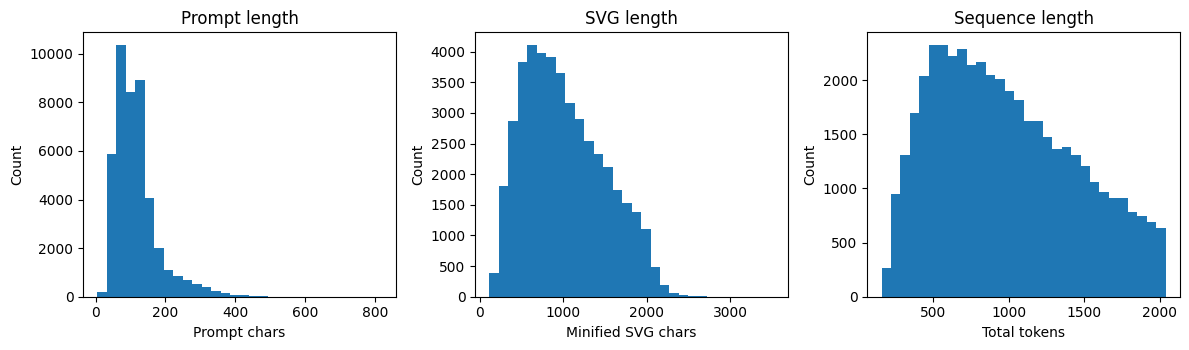

Saved figure -> /content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1/report_assets/figures/token_length_distribution.png


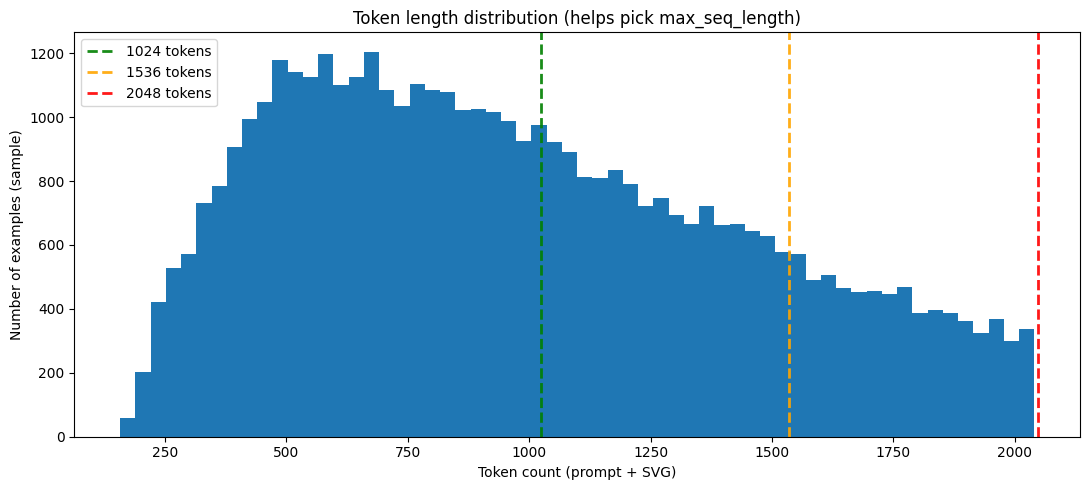


Fraction of examples fitting within max_seq_length:
1024 tokens: 57.3% of examples fit
1536 tokens: 84.7% of examples fit
2048 tokens: 100.0% of examples fit
2560 tokens: 100.0% of examples fit
3072 tokens: 100.0% of examples fit


In [13]:
# ===== REPORT REBUILD: LOAD SPLITS + DATASET FIGURES =====
raw_train_df = pd.read_csv(TRAIN_PATH)

assert TRAIN_SPLIT_PATH.exists(), f"Missing {TRAIN_SPLIT_PATH}"
assert VAL_SPLIT_PATH.exists(), f"Missing {VAL_SPLIT_PATH}"

train_part = pd.read_csv(TRAIN_SPLIT_PATH)
val_part = pd.read_csv(VAL_SPLIT_PATH)

train_df = pd.concat([train_part, val_part], axis=0, ignore_index=True)

prompt_col = pick_existing_col(train_df, ["prompt", "description", "text", "instruction"])
svg_ref_col = pick_existing_col(train_df, ["svg_min", "svg", "svg_clean", "min_svg", "svg_minified"])

# 如果保存的 split 没有长度列，就补算
if "min_chars" not in train_df.columns:
    train_df["min_chars"] = train_df[svg_ref_col].astype(str).str.len()

# 如果没有 token 统计列，就现算（通常 split 里已经有）
need_token_stats = ("svg_tokens" not in train_df.columns) or ("total_tokens" not in train_df.columns)
if need_token_stats:
    print("Token columns not found in saved split. Recomputing token stats...")
    tok = AutoTokenizer.from_pretrained(BASE_MODEL_NAME, trust_remote_code=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    prompt_token_counts = []
    svg_token_counts = []
    total_token_counts = []

    for p, s in zip(train_df[prompt_col].astype(str).tolist(), train_df[svg_ref_col].astype(str).tolist()):
        p_ids = tok.encode(p, add_special_tokens=False)
        s_ids = tok.encode(s, add_special_tokens=False)
        prompt_token_counts.append(len(p_ids))
        svg_token_counts.append(len(s_ids))
        total_token_counts.append(len(p_ids) + len(s_ids))

    train_df["svg_tokens"] = svg_token_counts
    train_df["total_tokens"] = total_token_counts

dataset_summary_df = pd.DataFrame([
    {"statistic": "raw_training_rows", "value": len(raw_train_df)},
    {"statistic": "rows_after_cleaning", "value": len(train_df)},
    {"statistic": "train_split_rows", "value": len(train_part)},
    {"statistic": "val_split_rows", "value": len(val_part)},
    {"statistic": "mean_prompt_chars", "value": round(float(train_df[prompt_col].astype(str).str.len().mean()), 2)},
    {"statistic": "mean_svg_chars", "value": round(float(train_df["min_chars"].mean()), 2)},
    {"statistic": "p90_svg_chars", "value": round(float(train_df["min_chars"].quantile(0.90)), 2)},
    {"statistic": "mean_svg_tokens", "value": round(float(train_df["svg_tokens"].mean()), 2)},
    {"statistic": "mean_total_tokens", "value": round(float(train_df["total_tokens"].mean()), 2)},
    {"statistic": "p90_total_tokens", "value": round(float(train_df["total_tokens"].quantile(0.90)), 2)},
])

display(dataset_summary_df)
save_table(dataset_summary_df, "dataset_summary")

# 1) dataset_histograms
fig = plt.figure(figsize=(12, 3.6))

plt.subplot(1, 3, 1)
plt.hist(train_df[prompt_col].astype(str).str.len(), bins=30)
plt.xlabel("Prompt chars")
plt.ylabel("Count")
plt.title("Prompt length")

plt.subplot(1, 3, 2)
plt.hist(train_df["min_chars"], bins=30)
plt.xlabel("Minified SVG chars")
plt.ylabel("Count")
plt.title("SVG length")

plt.subplot(1, 3, 3)
plt.hist(train_df["total_tokens"], bins=30)
plt.xlabel("Total tokens")
plt.ylabel("Count")
plt.title("Sequence length")

save_plot(fig, "dataset_histograms")
plt.show()

# 2) token_length_distribution with fit percentages
thresholds = [1024, 1536, 2048, 2560, 3072]
colors = ["green", "orange", "red", "purple", "brown"]

fig = plt.figure(figsize=(11, 5))
plt.hist(train_df["total_tokens"], bins=60)
for th, c in zip(thresholds[:3], colors[:3]):
    plt.axvline(th, linestyle="--", linewidth=2, color=c, alpha=0.9, label=f"{th} tokens")

plt.title("Token length distribution (helps pick max_seq_length)")
plt.xlabel("Token count (prompt + SVG)")
plt.ylabel("Number of examples (sample)")
plt.legend()

save_plot(fig, "token_length_distribution")
plt.show()

print("\nFraction of examples fitting within max_seq_length:")
for th in thresholds:
    frac = float((train_df["total_tokens"] <= th).mean())
    print(f"{th:>4} tokens: {100*frac:.1f}% of examples fit")

,item,value
0,base_model,Qwen/Qwen2.5-1.5B-Instruct
1,max_seq_length,2048
2,lora_r,32
3,lora_alpha,64
4,lora_dropout,0.05
5,per_device_train_batch_size,8
6,per_device_eval_batch_size,8
7,gradient_accumulation_steps,2
8,learning_rate,0.00002
9,weight_decay,0.01


Saved table -> /content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1/report_assets/tables/model_and_train_config.csv


,epoch,grad_norm,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
582,1.968976,NaN,NaN,NaN,5300,0.489973,69.1927,15.970,2.009
583,1.972692,0.326543,1.017759e-08,0.481561,5310,NaN,NaN,NaN,NaN
584,1.976407,0.281735,7.644822e-09,0.472124,5320,NaN,NaN,NaN,NaN
585,1.980123,0.296111,5.473710e-09,0.480500,5330,NaN,NaN,NaN,NaN
586,1.983838,0.308059,3.664329e-09,0.460495,5340,NaN,NaN,NaN,NaN
587,1.987553,0.295103,2.216747e-09,0.519636,5350,NaN,NaN,NaN,NaN
588,1.991269,0.265963,1.131014e-09,0.480312,5360,NaN,NaN,NaN,NaN
589,1.994984,0.281688,4.071698e-10,0.494402,5370,NaN,NaN,NaN,NaN
590,1.998700,0.296817,4.524136e-11,0.479247,5380,NaN,NaN,NaN,NaN
591,2.000000,NaN,NaN,NaN,5384,0.489958,69.1760,15.974,2.009


Saved table -> /content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1/report_assets/tables/training_log_tail.csv
Saved figure -> /content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1/report_assets/figures/training_curves.png


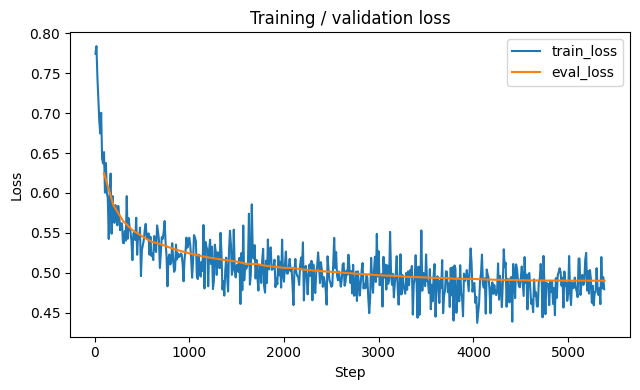

Best eval_loss: 0.4899578094482422


In [14]:
# ===== REPORT REBUILD: TRAIN CONFIG + TRAINING CURVES FROM CHECKPOINT =====
model_train_cfg = pd.DataFrame([
    {"item": "base_model", "value": CONFIG["base_model"]},
    {"item": "max_seq_length", "value": CONFIG["max_seq_length"]},
    {"item": "lora_r", "value": CONFIG["lora_r"]},
    {"item": "lora_alpha", "value": CONFIG["lora_alpha"]},
    {"item": "lora_dropout", "value": CONFIG["lora_dropout"]},
    {"item": "per_device_train_batch_size", "value": CONFIG["per_device_train_batch_size"]},
    {"item": "per_device_eval_batch_size", "value": CONFIG["per_device_eval_batch_size"]},
    {"item": "gradient_accumulation_steps", "value": CONFIG["gradient_accumulation_steps"]},
    {"item": "learning_rate", "value": CONFIG["learning_rate"]},
    {"item": "weight_decay", "value": CONFIG["weight_decay"]},
    {"item": "warmup_ratio", "value": CONFIG["warmup_ratio"]},
    {"item": "num_train_epochs", "value": CONFIG["num_train_epochs"]},
    {"item": "early_stopping_patience", "value": CONFIG["early_stopping_patience"]},
    {"item": "gen_max_new_tokens", "value": CONFIG["gen_max_new_tokens"]},
    {"item": "infer_batch_size", "value": CONFIG["infer_batch_size"]},
    {"item": "repetition_penalty", "value": CONFIG["repetition_penalty"]},
    {"item": "seed", "value": SEED},
    {"item": "gpu_name", "value": gpu_name},
])

display(model_train_cfg)
save_table(model_train_cfg, "model_and_train_config")

if TRAINER_STATE_PATH.exists():
    with open(TRAINER_STATE_PATH, "r") as f:
        trainer_state = json.load(f)
    log_history = trainer_state.get("log_history", [])
else:
    log_history = []

if len(log_history) == 0:
    print("No trainer_state.json or empty log_history.")
else:
    log_df = pd.DataFrame(log_history)
    display(log_df.tail(10))
    save_table(log_df.tail(10), "training_log_tail")

    fig = plt.figure(figsize=(6.5, 4.0))
    if "loss" in log_df.columns:
        tmp = log_df[["step", "loss"]].dropna()
        if len(tmp) > 0:
            plt.plot(tmp["step"], tmp["loss"], label="train_loss")
    if "eval_loss" in log_df.columns:
        tmp = log_df[["step", "eval_loss"]].dropna()
        if len(tmp) > 0:
            plt.plot(tmp["step"], tmp["eval_loss"], label="eval_loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Training / validation loss")
    plt.legend()
    save_plot(fig, "training_curves")
    plt.show()

    if "eval_loss" in log_df.columns:
        best_eval = log_df["eval_loss"].dropna().min()
        print("Best eval_loss:", best_eval)

In [15]:
# ===== REPORT REBUILD: LOAD SAVED MODEL FOR VALIDATION INFERENCE =====
assert ADAPTER_DIR.exists(), f"Missing adapter dir: {ADAPTER_DIR}"

infer_tokenizer = AutoTokenizer.from_pretrained(str(ADAPTER_DIR), trust_remote_code=True)
if infer_tokenizer.pad_token is None:
    infer_tokenizer.pad_token = infer_tokenizer.eos_token
infer_tokenizer.padding_side = "left"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    torch_dtype=DTYPE,
    device_map="auto",
    trust_remote_code=True,
)

infer_model = PeftModel.from_pretrained(base_model, str(ADAPTER_DIR))
infer_model.eval()

try:
    infer_model.print_trainable_parameters()
except Exception as e:
    print("Could not print trainable parameter summary:", e)

SYSTEM_PROMPT = globals().get(
    "SYSTEM_PROMPT",
    "You are an SVG generation assistant. Output only a valid SVG for the user's prompt."
)

print("Loaded inference model.")
print("Tokenizer vocab size:", len(infer_tokenizer))

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 0 || all params: 1,580,643,840 || trainable%: 0.0000
Loaded inference model.
Tokenizer vocab size: 151665


In [16]:
# ===== REPORT REBUILD: SMALL QUALITATIVE GRID (3x4, TWO-COLUMN FRIENDLY) =====
import re
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

QUAL_GRID_POOL = 48          # 先从 48 个 val 样本里挑
QUAL_GRID_PAIRS = 6          # 6 组 reference/prediction = 12 个小图
QUAL_GRID_ROWS = 3
QUAL_GRID_COLS = 4
QUAL_BATCH_SIZE = 4

val_prompt_col = pick_existing_col(val_part, ["prompt", "description", "text", "instruction"])
val_svg_ref_col = pick_existing_col(val_part, ["svg_min", "svg", "svg_clean", "min_svg", "svg_minified"])

# 默认用 best setting；如果没有，就回退到 greedy_384
if "best_setting_name" in globals():
    try:
        best_mx = int(str(best_setting_name).split("_")[-1])
    except Exception:
        best_mx = 384
else:
    best_mx = 384

print("Using max_new_tokens =", best_mx)

pool_df = val_part.sample(
    n=min(QUAL_GRID_POOL, len(val_part)),
    random_state=SEED + 123
).reset_index(drop=True)

pool_prompts = pool_df[val_prompt_col].astype(str).tolist()
pool_refs = pool_df[val_svg_ref_col].astype(str).tolist()

pool_outputs = generate_svg_batch_report(
    pool_prompts,
    max_new_tokens=best_mx,
    batch_size=QUAL_BATCH_SIZE
)

def compact_prompt_phrase(prompt, max_words=8):
    s = str(prompt).strip().replace("\n", " ")
    s = re.sub(r"\s+", " ", s)
    # 去掉一些常见开头，减少 caption 废话
    prefixes = [
        "the image shows ",
        "the image features ",
        "the image contains ",
        "a simple ",
        "an icon of ",
        "icon of ",
    ]
    low = s.lower()
    for p in prefixes:
        if low.startswith(p):
            s = s[len(p):]
            break
    words = s.split()
    if len(words) <= max_words:
        return s
    return " ".join(words[:max_words]) + " ..."

modes = [o["mode"] for o in pool_outputs]
model_idx = [i for i, m in enumerate(modes) if m == "model"]
fallback_idx = [i for i, m in enumerate(modes) if m == "fallback"]

# 优先挑 2 个 model 成功样例 + 4 个 fallback 样例，方便展示优缺点
selected = []
selected += model_idx[:2]
selected += fallback_idx[:4]

# 如果不够 6 组，就从剩余样本补足
remaining = [i for i in range(len(pool_df)) if i not in selected]
selected = (selected + remaining)[:QUAL_GRID_PAIRS]

# 为了排版更均衡，交错一下顺序：model/fallback 混排
selected_items = []
for idx in selected:
    selected_items.append({
        "idx": idx,
        "prompt": pool_prompts[idx],
        "ref_svg": pool_refs[idx],
        "pred_svg": pool_outputs[idx]["svg"],
        "mode": pool_outputs[idx]["mode"],
        "short_desc": compact_prompt_phrase(pool_prompts[idx], max_words=8),
    })

# 画 3x4：每组两列，左 reference，右 prediction
fig, axes = plt.subplots(QUAL_GRID_ROWS, QUAL_GRID_COLS, figsize=(11.5, 8.2))
axes = np.asarray(axes)

for pair_id, item in enumerate(selected_items):
    row = pair_id // 2
    block = pair_id % 2
    c0 = 2 * block
    c1 = c0 + 1

    ref_img = render_svg_white(item["ref_svg"], size=256)
    pred_img = render_svg_white(item["pred_svg"], size=256)

    axes[row, c0].imshow(ref_img)
    axes[row, c0].axis("off")
    axes[row, c0].set_title(f"Ref S{pair_id+1}", fontsize=10)

    axes[row, c1].imshow(pred_img)
    axes[row, c1].axis("off")
    axes[row, c1].set_title(f"Pred S{pair_id+1} ({item['mode']})", fontsize=10)

# 理论上正好 12 格，不需要隐藏多余子图；为了稳妥再写一遍
for ax in axes.flat:
    ax.set_facecolor("white")

qual_grid_path = save_plot(fig, "qualitative_grid_3x4")
plt.show()

# 保存 caption 用的文字
caption_rows = []
for i, item in enumerate(selected_items, start=1):
    caption_rows.append({
        "sample_id": f"S{i}",
        "mode": item["mode"],
        "short_description": item["short_desc"],
        "full_prompt": item["prompt"],
    })

caption_df = pd.DataFrame(caption_rows)
save_table(caption_df, "qualitative_grid_caption_items")
display(caption_df)

# 直接打印一个可粘贴进 LaTeX caption 的短文本
caption_items = []
for i, item in enumerate(selected_items, start=1):
    caption_items.append(f"S{i}: {item['short_desc']} ({item['mode']})")

caption_text = "; ".join(caption_items) + "."
print("\n=== CAPTION TEXT FOR LATEX ===")
print(caption_text)
print("\nSaved figure:", qual_grid_path)

Using max_new_tokens = 384


NameError: name 'generate_svg_batch_report' is not defined

In [ ]:
# ===== REPORT REBUILD: SMALL VALIDATION ABLATION + QUALITATIVE EXAMPLES =====
# 这一步不需要重跑 submission，只在 val split 上跑少量样本用于 report
# 如果 T4 太慢，把 VAL_EVAL_N 改成 24

VAL_EVAL_N = 48
VAL_BATCH_SIZE = 4
ABLATION_SETTINGS = [256, 384, 448]

val_prompt_col = pick_existing_col(val_part, ["prompt", "description", "text", "instruction"])
val_svg_ref_col = pick_existing_col(val_part, ["svg_min", "svg", "svg_clean", "min_svg", "svg_minified"])

val_eval_df = val_part.sample(n=min(VAL_EVAL_N, len(val_part)), random_state=SEED).reset_index(drop=True)
val_prompts = val_eval_df[val_prompt_col].astype(str).tolist()
val_refs = val_eval_df[val_svg_ref_col].astype(str).tolist()

SVG_START_RE = re.compile(r"<svg\b", flags=re.IGNORECASE)
SVG_END_RE = re.compile(r"</svg>", flags=re.IGNORECASE)

def build_chat_text(prompt):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": str(prompt)},
    ]
    return infer_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

def extract_svg_only(text):
    if not isinstance(text, str):
        return ""
    m = SVG_START_RE.search(text)
    if not m:
        return ""
    text = text[m.start():]
    end_matches = list(SVG_END_RE.finditer(text))
    if len(end_matches) == 0:
        return ""
    return text[:end_matches[-1].end()].strip()

def simple_fallback_svg(prompt):
    return '<svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256"><rect x="56" y="56" width="144" height="144" rx="24" fill="#111111"/></svg>'

def sanitize_basic_svg(svg_text, prompt):
    svg_text = extract_svg_only(svg_text)
    if len(svg_text) == 0:
        return {"svg": simple_fallback_svg(prompt), "mode": "fallback"}

    try:
        root = ET.fromstring(svg_text)
        if local_name(root.tag) != "svg":
            return {"svg": simple_fallback_svg(prompt), "mode": "fallback"}

        root.tag = "svg"
        root.attrib["xmlns"] = "http://www.w3.org/2000/svg"
        root.attrib["width"] = "256"
        root.attrib["height"] = "256"
        root.attrib["viewBox"] = "0 0 256 256"

        out = ET.tostring(root, encoding="unicode", short_empty_elements=True)

        # render check
        _ = cairosvg.svg2png(
            bytestring=out.encode("utf-8"),
            output_width=256,
            output_height=256,
        )
        return {"svg": out, "mode": "model"}

    except Exception:
        return {"svg": simple_fallback_svg(prompt), "mode": "fallback"}

def generate_svg_batch_report(prompts, max_new_tokens=384, batch_size=4):
    outputs = []
    for start in range(0, len(prompts), batch_size):
        batch_prompts = prompts[start:start + batch_size]
        chat_texts = [build_chat_text(p) for p in batch_prompts]

        inputs = infer_tokenizer(
            chat_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=CONFIG["max_seq_length"],
        )
        device = next(infer_model.parameters()).device
        inputs = {k: v.to(device) for k, v in inputs.items()}
        input_width = inputs["input_ids"].shape[1]

        with torch.inference_mode():
            output_ids = infer_model.generate(
                **inputs,
                do_sample=False,
                max_new_tokens=max_new_tokens,
                repetition_penalty=CONFIG["repetition_penalty"],
                pad_token_id=infer_tokenizer.pad_token_id,
                eos_token_id=infer_tokenizer.eos_token_id,
                use_cache=True,
            )

        for i, prompt in enumerate(batch_prompts):
            gen_ids = output_ids[i, input_width:]
            decoded = infer_tokenizer.decode(gen_ids, skip_special_tokens=True)
            final = sanitize_basic_svg(decoded, prompt)
            outputs.append(final)

    return outputs

def evaluate_generation_outputs(prompts, refs, outputs, setting_name):
    rows = []
    for prompt, gt_svg, out in zip(prompts, refs, outputs):
        pred_svg = out["svg"]
        mode = out.get("mode", "model")
        rows.append({
            "setting": setting_name,
            "mode": mode,
            "char_len": len(pred_svg),
            "path_count": count_paths(pred_svg),
            "ssim_proxy": compute_ssim_proxy(pred_svg, gt_svg),
            "edge_f1_proxy": compute_edge_f1_proxy(pred_svg, gt_svg),
        })
    df = pd.DataFrame(rows)
    summary = pd.DataFrame([{
        "setting": setting_name,
        "n": len(df),
        "model_rate": round(float((df["mode"] == "model").mean()), 4),
        "fallback_rate": round(float((df["mode"] == "fallback").mean()), 4),
        "mean_ssim_proxy": round(float(df["ssim_proxy"].mean()), 4),
        "mean_edge_f1_proxy": round(float(df["edge_f1_proxy"].mean()), 4),
        "avg_svg_len": round(float(df["char_len"].mean()), 2),
        "avg_path_count": round(float(df["path_count"].fillna(0).mean()), 2),
    }])
    return df, summary

all_eval_rows = []
all_summary_rows = []

for mx in ABLATION_SETTINGS:
    print(f"Running validation ablation for max_new_tokens={mx} ...")
    outputs = generate_svg_batch_report(val_prompts, max_new_tokens=mx, batch_size=VAL_BATCH_SIZE)
    eval_df, summary_df = evaluate_generation_outputs(val_prompts, val_refs, outputs, f"greedy_{mx}")
    all_eval_rows.append(eval_df)
    all_summary_rows.append(summary_df)

val_ablation_df = pd.concat(all_summary_rows, ignore_index=True).sort_values(
    ["mean_ssim_proxy", "mean_edge_f1_proxy"], ascending=False
).reset_index(drop=True)

display(val_ablation_df)
save_table(val_ablation_df, "val_ablation_summary")

fig = plt.figure(figsize=(6.5, 4.0))
x = np.arange(len(val_ablation_df))
plt.bar(x, val_ablation_df["mean_ssim_proxy"])
plt.xticks(x, val_ablation_df["setting"], rotation=20, ha="right")
plt.ylabel("Mean SSIM proxy")
plt.title("Validation ablation: SSIM proxy")
save_plot(fig, "ablation_ssim")
plt.show()

fig = plt.figure(figsize=(6.5, 4.0))
x = np.arange(len(val_ablation_df))
plt.bar(x, val_ablation_df["fallback_rate"])
plt.xticks(x, val_ablation_df["setting"], rotation=20, ha="right")
plt.ylabel("Fallback rate")
plt.title("Validation ablation: fallback rate")
save_plot(fig, "ablation_fallback")
plt.show()

best_setting_name = val_ablation_df.iloc[0]["setting"]
best_val_summary = val_ablation_df[val_ablation_df["setting"] == best_setting_name].copy()
display(best_val_summary)
save_table(best_val_summary, "best_val_summary")

# qualitative examples
best_mx = int(best_setting_name.split("_")[-1])
QUAL_N = min(6, len(val_eval_df))
qual_idx = np.linspace(0, len(val_eval_df) - 1, QUAL_N, dtype=int)
qual_outputs = generate_svg_batch_report([val_prompts[i] for i in qual_idx], max_new_tokens=best_mx, batch_size=VAL_BATCH_SIZE)

fig, axes = plt.subplots(QUAL_N, 2, figsize=(8, 3 * QUAL_N))
if QUAL_N == 1:
    axes = np.array([axes])

for row_i, idx in enumerate(qual_idx):
    gt_img = render_svg_white(val_refs[idx], size=256)
    pred_img = render_svg_white(qual_outputs[row_i]["svg"], size=256)

    axes[row_i, 0].imshow(gt_img)
    axes[row_i, 0].axis("off")
    axes[row_i, 0].set_title("Reference")

    axes[row_i, 1].imshow(pred_img)
    axes[row_i, 1].axis("off")
    short_prompt = textwrap.fill(val_prompts[idx][:90], width=28)
    mode = qual_outputs[row_i].get("mode", "model")
    axes[row_i, 1].set_title(f"Prediction ({mode})\n{short_prompt}")

save_plot(fig, "qualitative_examples")
plt.show()

print("Best setting by SSIM proxy:", best_setting_name)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Running validation ablation for max_new_tokens=256 ...


,metric,value
0,submission_rows,1000.000
1,mean_svg_len,188.670
2,median_svg_len,162.000
3,p90_svg_len,193.000
4,max_svg_len,731.000
5,mean_path_count,0.080
6,model_count_from_saved_log,79.000
7,fallback_count_from_saved_log,921.000
8,fallback_rate_from_saved_log,0.921
9,runtime_minutes_from_saved_log,39.250


Saved table -> /content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1/report_assets/tables/submission_summary.csv
Saved figure -> /content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1/report_assets/figures/submission_length_hist.png


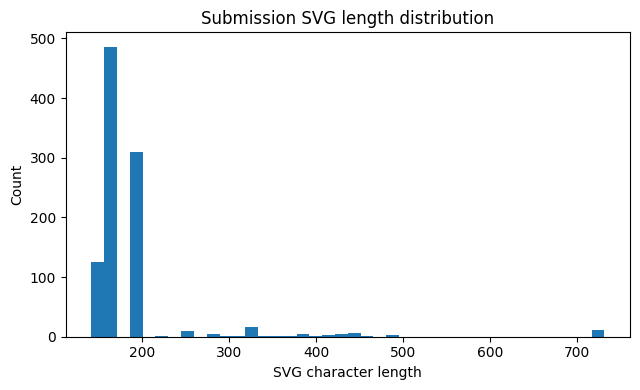

All report assets are in: /content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1/report_assets
Figures: /content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1/report_assets/figures
Tables : /content/drive/MyDrive/DL_midterm/svg_a100_stable_assistant_only_v1/report_assets/tables


In [21]:
# ===== REPORT REBUILD: FINAL SUBMISSION SUMMARY FROM SAVED CSV =====
assert SUBMISSION_PATH.exists(), f"Missing submission file: {SUBMISSION_PATH}"
sub_df = pd.read_csv(SUBMISSION_PATH)

# 这些数直接来自你保存下来的 submission 运行日志
# Done. Rows:1000, Model count:79, Fallback count:921, Fallback rate:0.921, Runtime:39.25 min
SUBMISSION_MODEL_COUNT = 79
SUBMISSION_FALLBACK_COUNT = 921
SUBMISSION_FALLBACK_RATE = 0.921
SUBMISSION_RUNTIME_MIN = 39.25

submission_summary_df = pd.DataFrame([
    {"metric": "submission_rows", "value": len(sub_df)},
    {"metric": "mean_svg_len", "value": round(float(sub_df["svg"].astype(str).str.len().mean()), 2)},
    {"metric": "median_svg_len", "value": round(float(sub_df["svg"].astype(str).str.len().median()), 2)},
    {"metric": "p90_svg_len", "value": round(float(sub_df["svg"].astype(str).str.len().quantile(0.90)), 2)},
    {"metric": "max_svg_len", "value": int(sub_df["svg"].astype(str).str.len().max())},
    {"metric": "mean_path_count", "value": round(float(sub_df["svg"].map(count_paths).fillna(0).mean()), 2)},
    {"metric": "model_count_from_saved_log", "value": SUBMISSION_MODEL_COUNT},
    {"metric": "fallback_count_from_saved_log", "value": SUBMISSION_FALLBACK_COUNT},
    {"metric": "fallback_rate_from_saved_log", "value": SUBMISSION_FALLBACK_RATE},
    {"metric": "runtime_minutes_from_saved_log", "value": SUBMISSION_RUNTIME_MIN},
])

display(submission_summary_df)
save_table(submission_summary_df, "submission_summary")

fig = plt.figure(figsize=(6.5, 4.0))
plt.hist(sub_df["svg"].astype(str).str.len(), bins=40)
plt.xlabel("SVG character length")
plt.ylabel("Count")
plt.title("Submission SVG length distribution")
save_plot(fig, "submission_length_hist")
plt.show()

print("All report assets are in:", REPORT_DIR)
print("Figures:", FIG_DIR)
print("Tables :", TABLE_DIR)

## Notes

- Keep a fixed seed, runtime logs, and invalid-generation counts (required by `contest_docs/05`).
- If you use Kaggle-packaged datasets (`svg-train-public`, `svg-test-public-prompts`, `svg-utils`), swap paths into the loading cells.
- For stricter alignment with Unsloth templates, copy the latest prompt-formatting snippets from the official Qwen3.5-2B notebook linked above.